In [2]:
import numpy as np
import matplotlib.pyplot as plt
from gridworld_env import get_task1_gridworld, get_task2_gridworld, get_task3_gridworld
from utils import paint_gridworld, get_grid
from plot_preferred_directions import plot_preferred_movement_direction
from RLagent import QLearningAgent, SARSAAgent, QLearningSoftmaxDecayingTau, SARSASoftmaxDecayingTau, QLearningSoftmaxDecayingTauTraces, SARSASoftmaxDecayingTauTraces, QLearningANN, SARSAANN


In [2]:

np.random.seed(68)  # for reproducibility
seeds = np.random.randint(0, 10000, size=100)
np.save('seeds.npy', seeds)


In [3]:

seeds = np.load('seeds.npy')
print(seeds)

[5618 2980 6384 9884 7704 5783 5332 1359 5238 1036 2348 4755 1839 1563
  139 8635 7349 9480 9985  602 4692 2955 4160 8458 8407 5998 9445 8508
 6295 1431 4978 8405 2473 8136 1786 3024 1772 1593 3117 2635 5087 2247
 5550 8730 5682 3275 5807 3625  878 5932 1295 3214 6626 3202 4299 1879
 9623 4173 7786  406 2017 9407 5866 2144 8596 9098 7619 7268 7271 8923
  171 3634 9038 3826  285 1403 5839 7555 3693 8285 4930 8105 7517 9727
 8342 5818 6232 1342  254 9987  642 5250 7046 1747 3462 4197 3388 2270
 5524 7834]


## A Look Around GridWorld

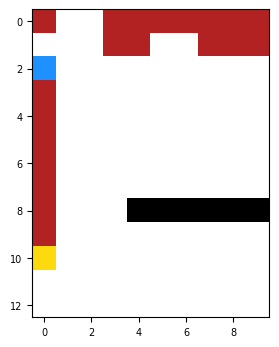

In [4]:
# Initiating the Environment. The method get_task1_gridworld
# initialises the environment for the task 1. Similarly there are methods to initialise the environment 
# for the other tasks
env1 = get_task1_gridworld()

# This is how the environment looks like
paint_gridworld(env1, figsize=(4,4), ticksize=7)

## Example of running a simulation 

In [5]:
reward_lst = []

# Initialise the environment
# An arbitary gamma value is used here. You may need to change this!
env1 = get_task1_gridworld()

# Reset the environment to start from the starting location. 
# The reset() method returns the state, reward, and whether the episode is done or not
# More information can be found under the definition of the method
_, state, reward, done = env1.reset()
reward_lst.append(reward)

# While the trial is not done, i.e. the agent has not fallen into lava,
# the maximum length of the episode has not been exceeded, and the target has not been reached
while not done:
    
    # Take a step using the step() function and passing in one of the available actions [0, 1, 2, 3] 
    # corresponding to ['N', 'S', 'E', 'W']
    # More information can be found under the definition of the method
    # In this very simple example for each step we choose a random action
    _, state, reward, done = env1.step(np.random.choice(4))
    reward_lst.append(reward)

print(f'Collected rewards of an episode: {reward_lst}')

Collected rewards of an episode: [0, -10.0]


# Task 1 - Single Target, Deterministic Rewards:

In [4]:
# Defining different parameter tuples for SARSA and Q-learning agents

# (gamma, alpha, epsilon/tau)
sarsa_parameters = [
    (0.9, 0.1, 0.8),
    (0.5, 0.5, 0.5),
    (0.1, 0.9, 0.2),
    (0.1, 0.5, 0.5),
    (0.5, 0.5, 0.1),
    (0.5, 0.5, 0.9),
    (0.8, 0.2, 0.7),
    (0.6, 0.4, 0.4),
    (0.3, 0.7, 0.3),
    (0.2, 0.8, 0.6),
    (0.7, 0.3, 0.8),
    (0.4, 0.6, 0.5),
    (0.5, 0.4, 0.3),
    (0.2, 0.7, 0.9),
    (0.6, 0.5, 0.2),
    (0.3, 0.6, 0.4),
    (0.4, 0.5, 0.6),
    (0.7, 0.4, 0.3),
    (0.5, 0.7, 0.8),
    (0.8, 0.3, 0.2),
]

# (gamma, alpha, epsilon/tau)
q_learning_parameters = [
    (0.9, 0.1, 0.8),
    (0.5, 0.5, 0.5),
    (0.1, 0.9, 0.2),
    (0.1, 0.5, 0.5),
    (0.5, 0.5, 0.1),
    (0.5, 0.5, 0.9),
    (0.8, 0.2, 0.7),
    (0.6, 0.4, 0.4),
    (0.3, 0.7, 0.3),
    (0.2, 0.8, 0.6),
    (0.7, 0.3, 0.8),
    (0.4, 0.6, 0.5),
    (0.5, 0.4, 0.3),
    (0.2, 0.7, 0.9),
    (0.6, 0.5, 0.2),
    (0.3, 0.6, 0.4),
    (0.4, 0.5, 0.6),
    (0.7, 0.4, 0.3),
    (0.5, 0.7, 0.8),
    (0.8, 0.3, 0.2),
]


In [6]:
def run_experiment(agent_class, env, gamma, alpha, epsilon, policy_type, n_episodes, seeds):
    rewards = []
    for seed in range(seeds):
        agent = agent_class(env=env, policy_type=policy_type, alpha=alpha, gamma=gamma, episodes=n_episodes)
        _, total_rewards, _ = agent.solve(epsilon=epsilon, seed=seed)
        rewards.append(total_rewards[-1])  
    average_reward = np.mean(rewards) 
    return average_reward

In [37]:
from gridworld_env import get_task1_gridworld


env1 = get_task1_gridworld()
n_episodes = 1000
seeds = np.load('seeds.npy')

results = []

for gamma, alpha, epsilon in sarsa_parameters:
    average_reward = run_experiment(SARSAAgent, env1, gamma, alpha, epsilon, 'epsilon-greedy', n_episodes, seeds)
    results.append(('SARSA', gamma, alpha, epsilon, average_reward))

for gamma, alpha, epsilon in q_learning_parameters:
    average_reward = run_experiment(QLearningAgent, env1, gamma, alpha, epsilon, 'epsilon-greedy', n_episodes, seeds)
    results.append(('Q-learning', gamma, alpha, epsilon, average_reward))

In [38]:
header = f"{'Agent':<12} {'Gamma':<6} {'Alpha':<6} {'Epsilon':<8} {'Avg Reward':<12}"
print(header)
print("=" * len(header))

for result in results:
    agent, gamma, alpha, epsilon, avg_reward = result
    print(f"{agent:<12} {gamma:<6} {alpha:<6} {epsilon:<8} {avg_reward:<12.2f}")


Agent        Gamma  Alpha  Epsilon  Avg Reward  
SARSA        0.9    0.1    0.8      -8.00       
SARSA        0.5    0.5    0.5      -5.00       
SARSA        0.1    0.9    0.2      -1.00       
SARSA        0.1    0.5    0.5      -1.00       
SARSA        0.5    0.5    0.1      350.00      
SARSA        0.5    0.5    0.9      -8.00       
SARSA        0.8    0.2    0.7      -7.00       
SARSA        0.6    0.4    0.4      147.00      
SARSA        0.3    0.7    0.3      0.00        
SARSA        0.2    0.8    0.6      -4.00       
SARSA        0.7    0.3    0.8      -4.00       
SARSA        0.4    0.6    0.5      0.00        
SARSA        0.5    0.4    0.3      149.00      
SARSA        0.2    0.7    0.9      -9.00       
SARSA        0.6    0.5    0.2      249.00      
SARSA        0.3    0.6    0.4      48.00       
SARSA        0.4    0.5    0.6      -1.00       
SARSA        0.7    0.4    0.3      298.00      
SARSA        0.5    0.7    0.8      -4.00       
SARSA        0.8    

Agent        Gamma  Alpha  Epsilon  Avg Reward  
SARSA        0.7000000000000001 0.4    0.6      50.70       
SARSA        0.2    0.4    0.6      -2.40       
SARSA        0.30000000000000004 0.4    0.30000000000000004 8.40        
SARSA        0.6    0.6    0.5      86.80       
SARSA        0.4    0.9    0.2      19.50       
Q-learning   0.30000000000000004 0.5    0.8      0.20        
Q-learning   0.8    0.8    0.9      0.20        
Q-learning   0.8    0.1    0.1      403.10      
Q-learning   0.4    0.2    0.5      56.30       
Q-learning   0.1    0.2    0.30000000000000004 234.80      


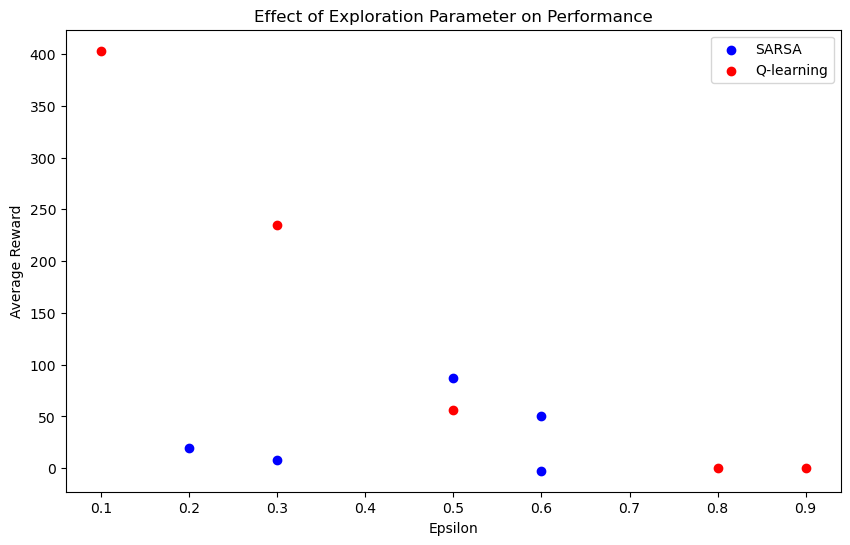

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
from RLagent import SARSAAgent, QLearningAgent
from gridworld_env import get_task1_gridworld

env1 = get_task1_gridworld()
n_episodes = 1000
seeds = np.load('seeds.npy')

# Parameter ranges
gamma_range = np.linspace(0.1, 0.9, 9)
alpha_range = np.linspace(0.1, 0.9, 9)
epsilon_range = np.linspace(0.1, 0.9, 9)

n_iterations = 5

def run_experiment(agent_class, env, gamma, alpha, epsilon, policy_type, n_episodes, seeds):
    rewards = []
    for seed in seeds:
        agent = agent_class(env=env, policy_type=policy_type, alpha=alpha, gamma=gamma, episodes=n_episodes)
        _, total_rewards, _ = agent.solve(epsilon=epsilon, seed=seed)
        rewards.append(total_rewards[-1])
    average_reward = np.mean(rewards)
    return average_reward

def execute_random_search(agent_class, agent_name):
    results = []
    for _ in range(n_iterations):
        gamma = random.choice(gamma_range)
        alpha = random.choice(alpha_range)
        epsilon = random.choice(epsilon_range)
        average_reward = run_experiment(agent_class, env1, gamma, alpha, epsilon, 'epsilon-greedy', n_episodes, seeds)
        results.append({'agent': agent_name, 'gamma': gamma, 'alpha': alpha, 'epsilon': epsilon, 'avg_reward': average_reward})
    return results

# random search for SARSA
sarsa_results = execute_random_search(SARSAAgent, 'SARSA')

# random search for Q-learning
q_learning_results = execute_random_search(QLearningAgent, 'Q-learning')

results = sarsa_results + q_learning_results

# Print results
header = f"{'Agent':<12} {'Gamma':<6} {'Alpha':<6} {'Epsilon':<8} {'Avg Reward':<12}"
print(header)
print("=" * len(header))

for result in results:
    print(f"{result['agent']:<12} {result['gamma']:<6} {result['alpha']:<6} {result['epsilon']:<8} {result['avg_reward']:<12.2f}")

# Visualizing results
fig, ax = plt.subplots(figsize=(10, 6))

sarsa_epsilons = [res['epsilon'] for res in sarsa_results]
sarsa_rewards = [res['avg_reward'] for res in sarsa_results]
q_learning_epsilons = [res['epsilon'] for res in q_learning_results]
q_learning_rewards = [res['avg_reward'] for res in q_learning_results]

ax.scatter(sarsa_epsilons, sarsa_rewards, label='SARSA', color='blue')
ax.scatter(q_learning_epsilons, q_learning_rewards, label='Q-learning', color='red')

ax.set_xlabel('Epsilon')
ax.set_ylabel('Average Reward')
ax.set_title('Effect of Exploration Parameter on Performance')
ax.legend()
plt.show()


Best cumulative rewards outcome out of all the experimented hyperparameters


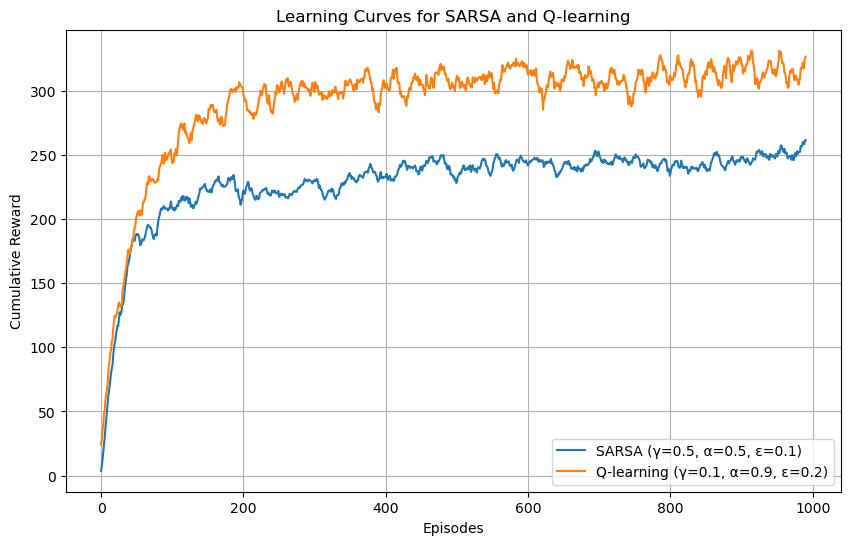

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from RLagent import SARSAAgent, QLearningAgent
from gridworld_env import get_task1_gridworld

env1 = get_task1_gridworld()
n_episodes = 1000
seeds = np.load('seeds.npy')

def run_experiment(agent_class, env, gamma, alpha, epsilon, policy_type, n_episodes):
    all_rewards = []
    for seed in seeds:
        agent = agent_class(env=env, policy_type=policy_type, alpha=alpha, gamma=gamma, episodes=n_episodes)
        _, total_rewards, _ = agent.solve(epsilon=epsilon, seed=seed)
        all_rewards.append(total_rewards)
    avg_rewards = np.mean(all_rewards, axis=0)
    
    return np.convolve(avg_rewards, np.ones(10)/10, mode='valid')

sarsa_params = (0.5, 0.5, 0.1)  # gamma, alpha, epsilon
q_learning_params = (0.1, 0.9, 0.2)  # gamma, alpha, epsilon

sarsa_rewards = run_experiment(SARSAAgent, env1, *sarsa_params, 'epsilon-greedy', n_episodes)
q_learning_rewards = run_experiment(QLearningAgent, env1, *q_learning_params, 'epsilon-greedy', n_episodes)

# Plotting the learning curves
plt.figure(figsize=(10, 6))
plt.plot(sarsa_rewards, label='SARSA (γ=0.5, α=0.5, ε=0.1)')
plt.plot(q_learning_rewards, label='Q-learning (γ=0.1, α=0.9, ε=0.2)')
plt.xlabel('Episodes')
plt.ylabel('Cumulative Reward')
plt.title('Learning Curves for SARSA and Q-learning')
plt.legend()
plt.grid(True)
plt.show()

Worst outcome out of all the experimented hyperparameters

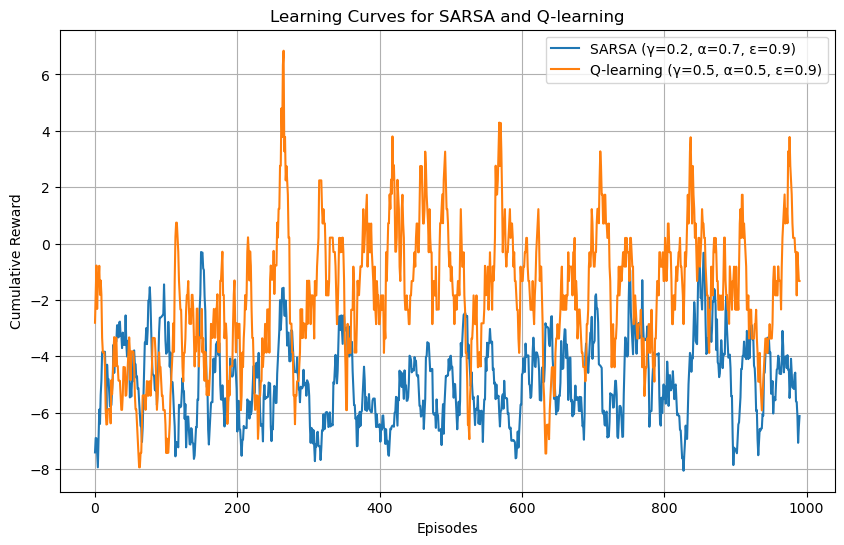

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from RLagent import SARSAAgent, QLearningAgent
from gridworld_env import get_task1_gridworld

env1 = get_task1_gridworld()
n_episodes = 1000
seeds = np.load('seeds.npy')

def run_experiment(agent_class, env, gamma, alpha, epsilon, policy_type, n_episodes):
    all_rewards = []
    for seed in seeds:
        agent = agent_class(env=env, policy_type=policy_type, alpha=alpha, gamma=gamma, episodes=n_episodes)
        _, total_rewards, _ = agent.solve(epsilon=epsilon, seed=seed)
        all_rewards.append(total_rewards)
    avg_rewards = np.mean(all_rewards, axis=0)
    
    return np.convolve(avg_rewards, np.ones(10)/10, mode='valid')

sarsa_params = (0.2, 0.7, 0.9)  # gamma, alpha, epsilon
q_learning_params = (0.5, 0.9, 0.9)  # gamma, alpha, epsilon

sarsa_rewards = run_experiment(SARSAAgent, env1, *sarsa_params, 'epsilon-greedy', n_episodes)
q_learning_rewards = run_experiment(QLearningAgent, env1, *q_learning_params, 'epsilon-greedy', n_episodes)

# Plotting the learning curves
plt.figure(figsize=(10, 6))
plt.plot(sarsa_rewards, label='SARSA (γ=0.2, α=0.7, ε=0.9)')
plt.plot(q_learning_rewards, label='Q-learning (γ=0.5, α=0.5, ε=0.9)')
plt.xlabel('Episodes')
plt.ylabel('Cumulative Reward')
plt.title('Learning Curves for SARSA and Q-learning')
plt.legend()
plt.grid(True)
plt.show()

Plot Preferred Directions

Number of states from environment: 124
Number of elements in policy array: 124
Number of steps taken: 1000


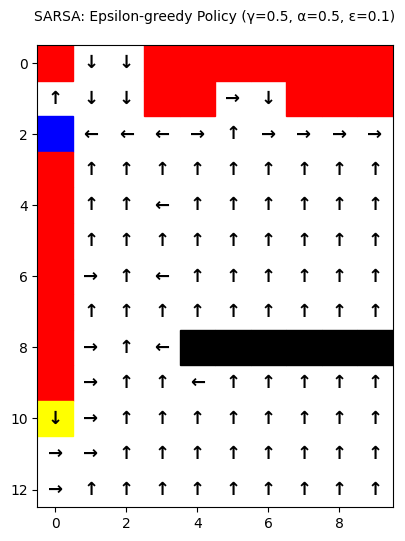

Number of states from environment: 124
Number of elements in policy array: 124
Number of steps taken: 1000


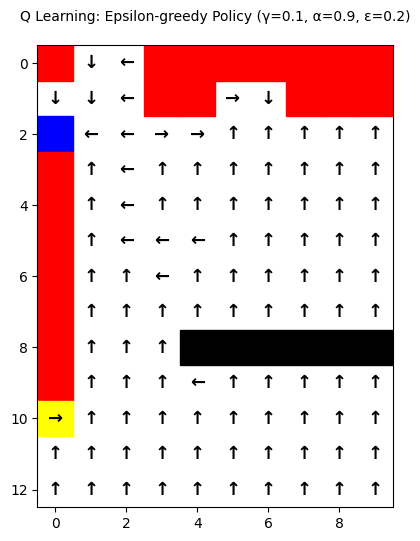

In [3]:
# Best Plot Preferred Direction for Single Target, Deterministic Reward with epsilon-greedy
import numpy as np
import matplotlib.pyplot as plt
from RLagent import SARSAAgent, QLearningAgent
from plot_preferred_directions import plot_preferred_movement_direction
from gridworld_env import get_task1_gridworld

env1 = get_task1_gridworld()
n_episodes = 1000
policy_type = "epsilon-greedy"
seeds = np.load('seeds.npy')

# SARSA
gamma = 0.5
alpha = 0.5
epsilon = 0.1

agent = SARSAAgent(env=env1, policy_type=policy_type, alpha=alpha, gamma=gamma, episodes=n_episodes)
policy, rewards, steps = agent.solve(epsilon=epsilon)
print("Number of states from environment:", env1.get_state_size())
print("Number of elements in policy array:", policy.size)
print("Number of steps taken:", len(steps))
title = f"SARSA: {policy_type.capitalize()} Policy (γ={gamma}, α={alpha}, ε={epsilon})"
plot_preferred_movement_direction(agent, env1, title)


# Q Learning 
gamma = 0.1
alpha = 0.9
epsilon = 0.2

agent = QLearningAgent(env=env1, policy_type=policy_type, alpha=alpha, gamma=gamma, episodes=n_episodes)
policy, rewards, steps = agent.solve(epsilon=epsilon)
print("Number of states from environment:", env1.get_state_size())
print("Number of elements in policy array:", policy.size)
print("Number of steps taken:", len(steps))
title = f"Q Learning: {policy_type.capitalize()} Policy (γ={gamma}, α={alpha}, ε={epsilon})"
plot_preferred_movement_direction(agent, env1, title)

With Softmax Policy

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from RLagent import SARSAAgent, QLearningAgent
from gridworld_env import get_task1_gridworld

env1 = get_task1_gridworld()
n_episodes = 1000
seeds = np.load('seeds.npy')

def run_experiment(agent_class, env, gamma, alpha, tau, policy_type, n_episodes):
    rewards = []
    for seed in range(seeds):
        agent = agent_class(env=env, policy_type=policy_type, alpha=alpha, gamma=gamma, episodes=n_episodes)
        _, total_rewards, _ = agent.solve(tau=tau, seed=seed)
        rewards.append(total_rewards[-1])  
    average_reward = np.mean(rewards) 
    return average_reward 
results = []

# Run experiments for SARSA
for gamma, alpha, tau in sarsa_parameters:
    average_reward = run_experiment(SARSAAgent, env1, gamma, alpha, tau, 'softmax', n_episodes)
    results.append(('SARSA', gamma, alpha, tau, average_reward))

# Run experiments for Q-learning
for gamma, alpha, tau in q_learning_parameters:
    average_reward = run_experiment(QLearningAgent, env1, gamma, alpha, tau, 'softmax', n_episodes)
    results.append(('Q-learning', gamma, alpha, tau, average_reward))

In [10]:
header = f"{'Agent':<12} {'Gamma':<6} {'Alpha':<6} {'Tau':<8} {'Avg Reward':<12}"
print(header)
print("=" * len(header))

for result in results:
    agent, gamma, alpha, epsilon, avg_reward = result
    print(f"{agent:<12} {gamma:<6} {alpha:<6} {epsilon:<8} {avg_reward:<12.2f}")


Agent        Gamma  Alpha  Tau      Avg Reward  
SARSA        0.9    0.1    0.8      500.00      
SARSA        0.5    0.5    0.5      500.00      
SARSA        0.1    0.9    0.2      350.00      
SARSA        0.1    0.5    0.5      500.00      
SARSA        0.5    0.5    0.1      500.00      
SARSA        0.5    0.5    0.9      500.00      
SARSA        0.8    0.2    0.7      500.00      
SARSA        0.6    0.4    0.4      500.00      
SARSA        0.3    0.7    0.3      450.00      
SARSA        0.2    0.8    0.6      450.00      
SARSA        0.7    0.3    0.8      500.00      
SARSA        0.4    0.6    0.5      500.00      
SARSA        0.5    0.4    0.3      500.00      
SARSA        0.2    0.7    0.9      400.00      
SARSA        0.6    0.5    0.2      500.00      
SARSA        0.3    0.6    0.4      400.00      
SARSA        0.4    0.5    0.6      450.00      
SARSA        0.7    0.4    0.3      500.00      
SARSA        0.5    0.7    0.8      500.00      
SARSA        0.8    

Plot best results graph using softmax

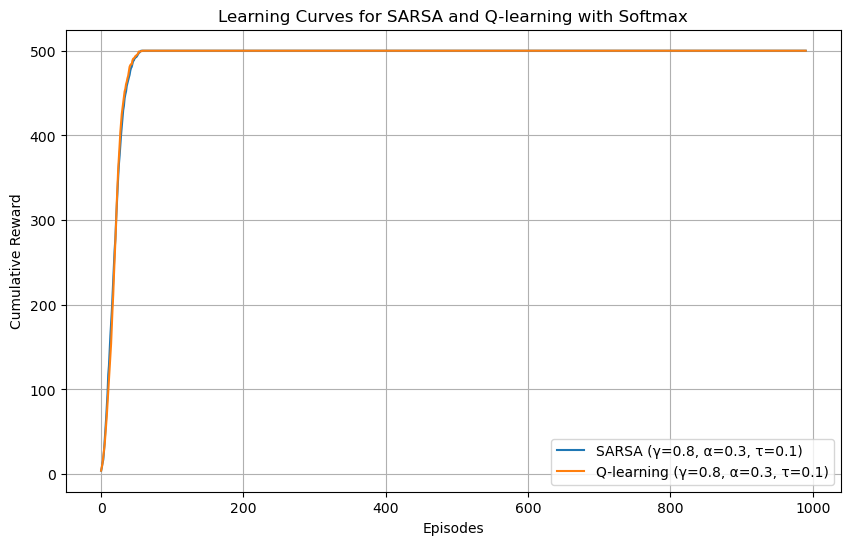

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from RLagent import SARSAAgent, QLearningAgent
from gridworld_env import get_task1_gridworld

env1 = get_task1_gridworld()
n_episodes = 1000
seeds = np.load('seeds.npy')

def run_experiment(agent_class, env, gamma, alpha, tau, policy_type, n_episodes):
    all_rewards = []
    for seed in seeds:
        agent = agent_class(env=env, policy_type=policy_type, alpha=alpha, gamma=gamma, episodes=n_episodes)
        _, total_rewards, _ = agent.solve(tau=tau, seed=seed)
        all_rewards.append(total_rewards)
    
    avg_rewards = np.mean(all_rewards, axis=0)

    return np.convolve(avg_rewards, np.ones(10)/10, mode='valid')

params = (0.8, 0.3, 0.1)  # gamma, alpha, tau


sarsa_rewards = run_experiment(SARSAAgent, env1, *params, 'softmax', n_episodes)

q_learning_rewards = run_experiment(QLearningAgent, env1, *params, 'softmax', n_episodes)

# Plotting the learning curves
plt.figure(figsize=(10, 6))
plt.plot(sarsa_rewards, label='SARSA (γ=0.8, α=0.3, τ=0.1)')
plt.plot(q_learning_rewards, label='Q-learning (γ=0.8, α=0.3, τ=0.1)')
plt.xlabel('Episodes')
plt.ylabel('Cumulative Reward')
plt.title('Learning Curves for SARSA and Q-learning with Softmax')
plt.legend()
plt.grid(True)
plt.show()

# Task 2 - Dual Targets with Stochastic Rewards

In [24]:

env2 = get_task2_gridworld()

goal_1_rewards = []
goal_2_rewards = []

def get_goal_state(env, state):
    for goal_loc in env.get_goal_loc():
        if state == env._get_state_from_loc(goal_loc):
            return goal_loc
    return None

ql = QLearningAgent(env2, policy_type='softmax', gamma=0.8, alpha=0.3, episodes=1000)
_, episode_rewards, _ = ql.solve(tau=0.1)

for state in range(env2.get_state_size()):
    goal_loc = get_goal_state(env2, state)
    if goal_loc == env2.get_goal_loc()[0]:
        goal_1_rewards.extend(episode_rewards)
    elif goal_loc == env2.get_goal_loc()[1]:
        goal_2_rewards.extend(episode_rewards)

# Analyze the average rewards
if goal_1_rewards:  
    print(f"Goal 1 at {env2.get_goal_loc()[0]}: Mean reward = {np.mean(goal_1_rewards)}")
else:
    print(f"Goal 1 at {env2.get_goal_loc()[0]}: No rewards recorded")

if goal_2_rewards:
    print(f"Goal 2 at {env2.get_goal_loc()[1]}: Mean reward = {np.mean(goal_2_rewards)}")
else:
    print(f"Goal 2 at {env2.get_goal_loc()[1]}: No rewards recorded")

goal_1_rewards = []
goal_2_rewards = []

sarsa = SARSAAgent(env2, policy_type='softmax', gamma=0.8, alpha=0.3, episodes=1000)
_, episode_rewards, _ = sarsa.solve(tau=0.1)

for state in range(env2.get_state_size()):
    goal_loc = get_goal_state(env2, state)
    if goal_loc == env2.get_goal_loc()[0]:
        goal_1_rewards.extend(episode_rewards)
    elif goal_loc == env2.get_goal_loc()[1]:
        goal_2_rewards.extend(episode_rewards)

# Analyze the average rewards
if goal_1_rewards:  # Check if there are any rewards recorded for the goal
    print(f"Goal 1 at {env2.get_goal_loc()[0]}: Mean reward = {np.mean(goal_1_rewards)}")
else:
    print(f"Goal 1 at {env2.get_goal_loc()[0]}: No rewards recorded")

if goal_2_rewards:  # Check if there are any rewards recorded for the goal
    print(f"Goal 2 at {env2.get_goal_loc()[1]}: Mean reward = {np.mean(goal_2_rewards)}")
else:
    print(f"Goal 2 at {env2.get_goal_loc()[1]}: No rewards recorded")


Goal 1 at (2, 0): Mean reward = 295.47972839091926
Goal 2 at (6, 9): Mean reward = 295.47972839091926
Goal 1 at (2, 0): Mean reward = 681.7263860072769
Goal 2 at (6, 9): Mean reward = 681.7263860072769


In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Function to plot learning curves
def plot_learning_curve(episode_rewards1, episode_rewards2, title):
    plt.figure(figsize=(10, 5))
    plt.plot(episode_rewards1)
    plt.plot(episode_rewards2)
    plt.xlabel('Episodes')
    plt.ylabel('Cumulative Reward')
    plt.title(title)
    plt.show()
    
env1 = get_task1_gridworld()
env2 = get_task2_gridworld()

# Hyperparameters
gamma = 0.8
alpha = 0.3
episodes = 1000
tau = 0.1

# Initialize reward tracking variables
def run_agent(agent_class, policy_type, env):
    agent = agent_class(env, policy_type=policy_type, gamma=gamma, alpha=alpha, episodes=episodes)
    policy, episode_rewards, total_steps = agent.solve(tau)
    return np.convolve(episode_rewards, np.ones(10)/10, mode='valid')

# Run agents with epsilon-greedy policy
sarsa_rewards_env1 = run_agent(SARSAAgent, 'softmax', env1)
qlearning_rewards_env1 = run_agent(QLearningAgent, 'softmax', env1)

# Run agents with Softmax policy
sarsa_rewards_env2 = run_agent(SARSAAgent, 'softmax', env2)
qlearning_rewards_env2 = run_agent(QLearningAgent, 'softmax', env2)


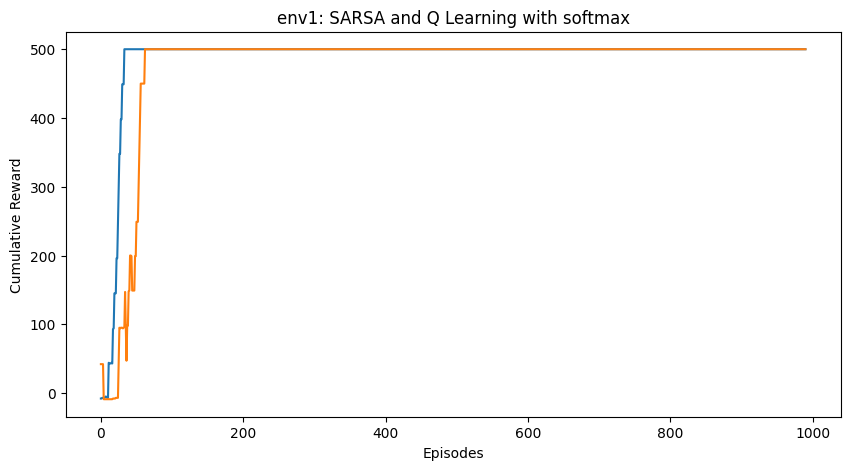

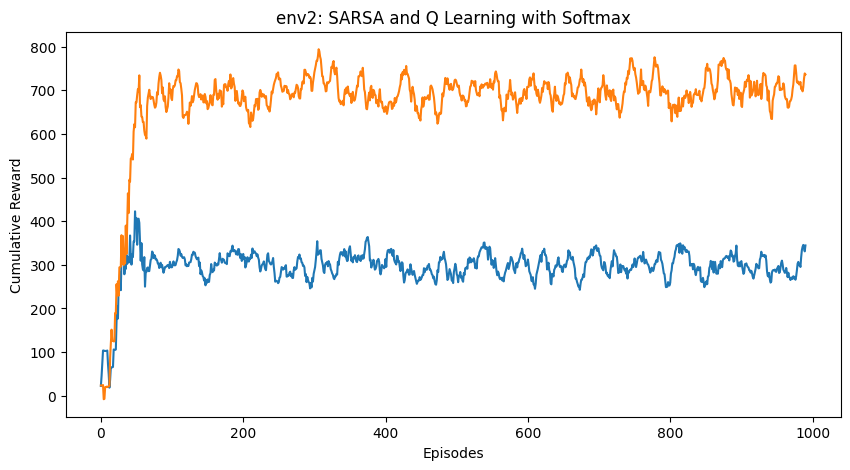

In [53]:

plot_learning_curve(sarsa_rewards_env1, qlearning_rewards_env1, 'env1: SARSA and Q Learning with softmax')

plot_learning_curve(sarsa_rewards_env2, qlearning_rewards_env2, 'env2: SARSA and Q Learning with Softmax')


In [15]:
import matplotlib.pyplot as plt
import numpy as np

def find_stability_point(steps, window_size=10, threshold=10):
    """
    Find the stability point where the steps to reach the goal become stable.
    """
    for i in range(len(steps) - window_size):
        window = steps[i:i + window_size]
        if max(window) - min(window) <= threshold:
            return i + window_size
    return len(steps)

env1 = get_task1_gridworld()
env2 = get_task2_gridworld()

# Hyperparameters
gamma = 0.8
alpha = 0.3
episodes = 1000
tau = 0.1

# Initialize reward tracking variables
def run_agent(agent_class, policy_type, env):
    agent = agent_class(env, policy_type=policy_type, gamma=gamma, alpha=alpha, episodes=episodes)
    policy, episode_rewards, total_steps = agent.solve(tau, seed=68)
    return np.convolve(total_steps, np.ones(10)/10, mode='valid')

sarsa_steps_env1 = run_agent(SARSAAgent, 'softmax', env1)
qlearning_steps_env1 = run_agent(QLearningAgent, 'softmax', env1)

sarsa_stability_point_env1 = find_stability_point(sarsa_steps_env1)
qlearning_stability_point_env1 = find_stability_point(qlearning_steps_env1)

print(f"SARSA Stability Point (Env1): {sarsa_stability_point_env1}")
print(f"Q-Learning Stability Point (Env1): {qlearning_stability_point_env1}")

sarsa_steps_env2 = run_agent(SARSAAgent, 'softmax', env2)
qlearning_steps_env2 = run_agent(QLearningAgent, 'softmax', env2)

sarsa_stability_point_env2 = find_stability_point(sarsa_steps_env2)
qlearning_stability_point_env2 = find_stability_point(qlearning_steps_env2)

print(f"SARSA Stability Point (Env2): {sarsa_stability_point_env2}")
print(f"Q-Learning Stability Point (Env2): {qlearning_stability_point_env2}")



SARSA Stability Point (Env1): 43
Q-Learning Stability Point (Env1): 57
SARSA Stability Point (Env2): 78
Q-Learning Stability Point (Env2): 68


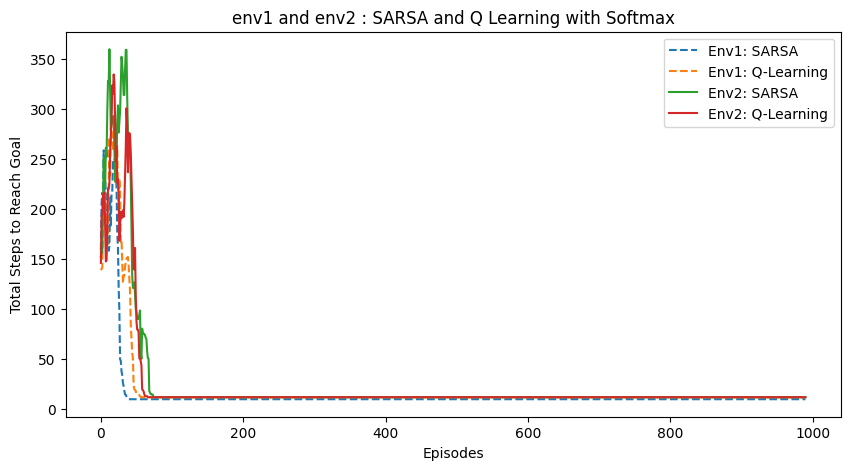

In [16]:
# Function to plot learning curves
def plot_learning_curve(steps1, steps2, steps3, steps4, title):
    plt.figure(figsize=(10, 5))
    plt.plot(steps1, label='Env1: SARSA', linestyle="--")
    plt.plot(steps2, label='Env1: Q-Learning', linestyle="--")
    plt.plot(steps3, label='Env2: SARSA', linestyle="-")
    plt.plot(steps4, label='Env2: Q-Learning', linestyle="-")
    plt.xlabel('Episodes')
    plt.ylabel('Total Steps to Reach Goal')
    plt.title(title)
    plt.legend()
    plt.show()


plot_learning_curve(sarsa_steps_env1, qlearning_steps_env1, sarsa_steps_env2, qlearning_steps_env2, 'env1 and env2 : SARSA and Q Learning with Softmax')

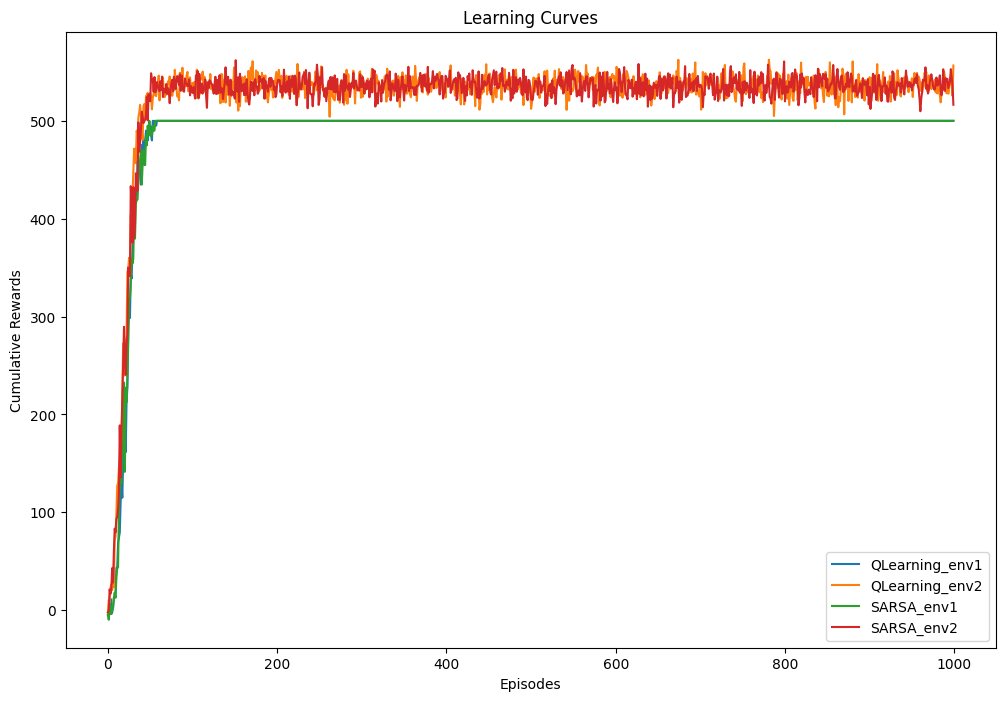

[0.9760000000000001, 0.9801299999999997, 0.97603, 0.98008]


In [14]:
import numpy as np
import matplotlib.pyplot as plt

def run_experiment(env, agent_class, episodes, seeds, gamma, alpha, tau):
    all_rewards = []
    success_rates = []

    for seed in seeds:
        agent = agent_class(env, episodes=episodes, gamma=gamma, alpha=alpha)
        _, rewards, _ = agent.solve(seed=seed, tau=tau)
        
        # Calculate success rate
        success_count = sum([1 for r in rewards if r > 0])  
        success_rate = success_count / episodes
        
        all_rewards.append(rewards)
        success_rates.append(success_rate)

    avg_rewards = np.mean(all_rewards, axis=0)
    std_rewards = np.std(all_rewards, axis=0)
    avg_success_rate = np.mean(success_rates)
    return avg_rewards, std_rewards, avg_success_rate

episodes = 1000
seeds = np.load('seeds.npy')

env1 = get_task1_gridworld()  # Single target, deterministic
env2 = get_task2_gridworld()  # Dual targets, stochastic

agents = {
    'QLearning': QLearningAgent,
    'SARSA': SARSAAgent
}

results = {}
for agent_name, agent_class in agents.items():
    results[f'{agent_name}_env1'] = run_experiment(env1, agent_class, episodes, seeds, gamma=0.8, alpha=0.3, tau=0.1)
    results[f'{agent_name}_env2'] = run_experiment(env2, agent_class, episodes, seeds, gamma=0.8, alpha=0.3, tau=0.1)

# Plotting Learning Curves
plt.figure(figsize=(12, 8))
for key in results:
    avg_rewards, std_rewards, _ = results[key]
    plt.plot(avg_rewards, label=key)
plt.xlabel('Episodes')
plt.ylabel('Cumulative Rewards')
plt.legend()
plt.title('Learning Curves')
plt.show()

labels = [key for key in results]
success_rate_values = [results[key][2] for key in results]

print(success_rate_values)


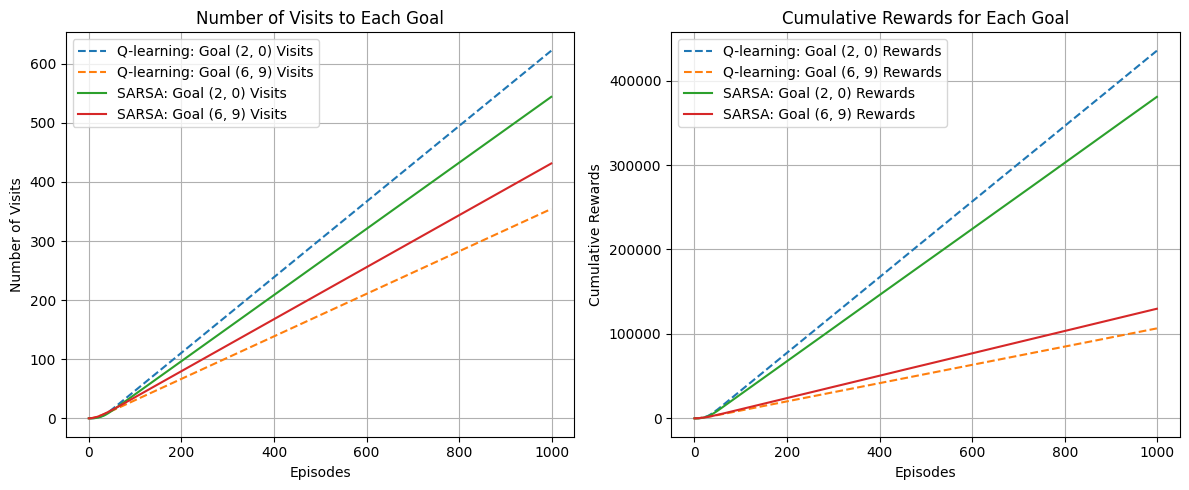

In [4]:
from gridworld_env import get_task2_gridworld
import numpy as np
import matplotlib.pyplot as plt
from RLagent import QLearningSoftmaxDecayingTau, SARSASoftmaxDecayingTau

gridworld = get_task2_gridworld()
seeds = np.load('seeds.npy')

learning_curves_sarsa = {'goal_1_visits': [], 'goal_2_visits': [], 'goal_1_rewards': [], 'goal_2_rewards': []}
learning_curves_qlearning = {'goal_1_visits': [], 'goal_2_visits': [], 'goal_1_rewards': [], 'goal_2_rewards': []}

for seed in seeds:
    # Q-learning
    ql = QLearningSoftmaxDecayingTau(gridworld, tau_initial=1.0, tau_min=0.1, decay_rate=0.99, alpha=0.3, gamma=0.8, episodes=1000)
    Q_ql, _, _, _ = ql.solve(seed=seed)
    learning_curves_qlearning['goal_1_visits'].append(ql.goal_1_visits)
    learning_curves_qlearning['goal_2_visits'].append(ql.goal_2_visits)
    learning_curves_qlearning['goal_1_rewards'].append(ql.goal_1_rewards)
    learning_curves_qlearning['goal_2_rewards'].append(ql.goal_2_rewards)

    # SARSA
    sarsa = SARSASoftmaxDecayingTau(gridworld, tau_initial=1.0, tau_min=0.1, decay_rate=0.99, alpha=0.3, gamma=0.8, episodes=1000)
    Q_sarsa, _, _, _ = sarsa.solve(seed=seed)
    learning_curves_sarsa['goal_1_visits'].append(sarsa.goal_1_visits)
    learning_curves_sarsa['goal_2_visits'].append(sarsa.goal_2_visits)
    learning_curves_sarsa['goal_1_rewards'].append(sarsa.goal_1_rewards)
    learning_curves_sarsa['goal_2_rewards'].append(sarsa.goal_2_rewards)

# Average learning curve data across seeds
avg_goal_1_visits_qlearning = np.mean(learning_curves_qlearning['goal_1_visits'], axis=0)
avg_goal_2_visits_qlearning = np.mean(learning_curves_qlearning['goal_2_visits'], axis=0)
avg_goal_1_rewards_qlearning = np.mean(learning_curves_qlearning['goal_1_rewards'], axis=0)
avg_goal_2_rewards_qlearning = np.mean(learning_curves_qlearning['goal_2_rewards'], axis=0)

avg_goal_1_visits_sarsa = np.mean(learning_curves_sarsa['goal_1_visits'], axis=0)
avg_goal_2_visits_sarsa = np.mean(learning_curves_sarsa['goal_2_visits'], axis=0)
avg_goal_1_rewards_sarsa = np.mean(learning_curves_sarsa['goal_1_rewards'], axis=0)
avg_goal_2_rewards_sarsa = np.mean(learning_curves_sarsa['goal_2_rewards'], axis=0)

# Plot the learning curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(avg_goal_1_visits_qlearning, label="Q-learning: Goal (2, 0) Visits", linestyle="--")
plt.plot(avg_goal_2_visits_qlearning, label="Q-learning: Goal (6, 9) Visits", linestyle="--")
plt.plot(avg_goal_1_visits_sarsa, label="SARSA: Goal (2, 0) Visits", linestyle="-")
plt.plot(avg_goal_2_visits_sarsa, label="SARSA: Goal (6, 9) Visits", linestyle="-")
plt.xlabel("Episodes")
plt.ylabel("Number of Visits")
plt.title("Number of Visits to Each Goal")
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(avg_goal_1_rewards_qlearning, label="Q-learning: Goal (2, 0) Rewards", linestyle="--")
plt.plot(avg_goal_2_rewards_qlearning, label="Q-learning: Goal (6, 9) Rewards", linestyle="--")
plt.plot(avg_goal_1_rewards_sarsa, label="SARSA: Goal (2, 0) Rewards", linestyle="-")
plt.plot(avg_goal_2_rewards_sarsa, label="SARSA: Goal (6, 9) Rewards", linestyle="-")
plt.xlabel("Episodes")
plt.ylabel("Cumulative Rewards")
plt.title("Cumulative Rewards for Each Goal")
plt.legend()
plt.grid()


plt.tight_layout()
plt.show()


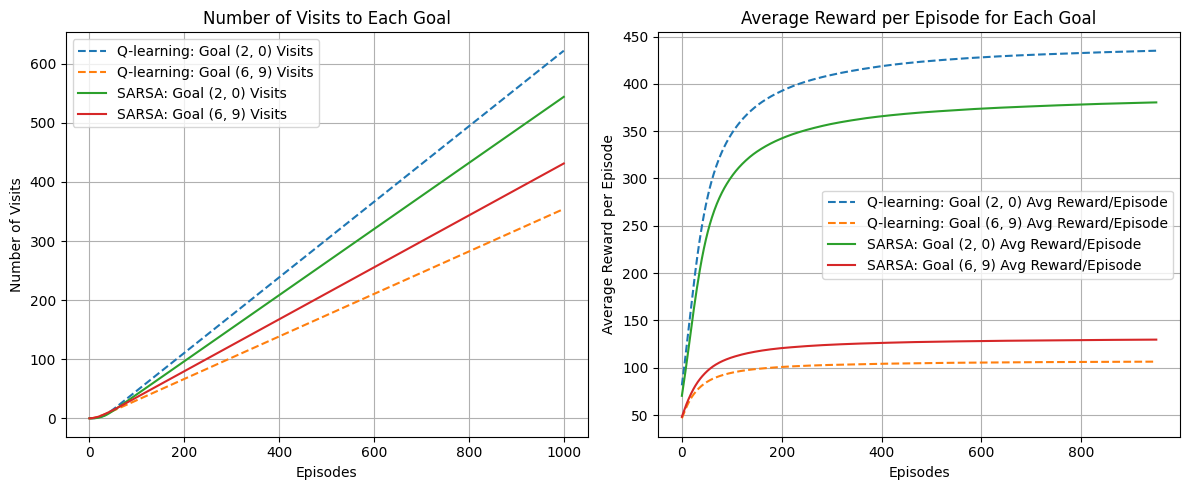

In [21]:
# Calculate average reward per episode
episodes=1000

avg_reward_per_episode_qlearning_goal_1 = np.mean(learning_curves_qlearning['goal_1_rewards'], axis=0) / np.arange(1, episodes + 1)
avg_reward_per_episode_qlearning_goal_2 = np.mean(learning_curves_qlearning['goal_2_rewards'], axis=0) / np.arange(1, episodes + 1)
avg_reward_per_episode_sarsa_goal_1 = np.mean(learning_curves_sarsa['goal_1_rewards'], axis=0) / np.arange(1, episodes + 1)
avg_reward_per_episode_sarsa_goal_2 = np.mean(learning_curves_sarsa['goal_2_rewards'], axis=0) / np.arange(1, episodes + 1)

# Calculate moving average for better visualization
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

window_size = 50
ma_avg_reward_qlearning_goal_1 = moving_average(avg_reward_per_episode_qlearning_goal_1, window_size)
ma_avg_reward_qlearning_goal_2 = moving_average(avg_reward_per_episode_qlearning_goal_2, window_size)
ma_avg_reward_sarsa_goal_1 = moving_average(avg_reward_per_episode_sarsa_goal_1, window_size)
ma_avg_reward_sarsa_goal_2 = moving_average(avg_reward_per_episode_sarsa_goal_2, window_size)

# Plot the learning curves with moving average
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(avg_goal_1_visits_qlearning, label="Q-learning: Goal (2, 0) Visits", linestyle="--")
plt.plot(avg_goal_2_visits_qlearning, label="Q-learning: Goal (6, 9) Visits", linestyle="--")
plt.plot(avg_goal_1_visits_sarsa, label="SARSA: Goal (2, 0) Visits", linestyle="-")
plt.plot(avg_goal_2_visits_sarsa, label="SARSA: Goal (6, 9) Visits", linestyle="-")
plt.xlabel("Episodes")
plt.ylabel("Number of Visits")
plt.title("Number of Visits to Each Goal")
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(ma_avg_reward_qlearning_goal_1, label="Q-learning: Goal (2, 0) Avg Reward/Episode", linestyle="--")
plt.plot(ma_avg_reward_qlearning_goal_2, label="Q-learning: Goal (6, 9) Avg Reward/Episode", linestyle="--")
plt.plot(ma_avg_reward_sarsa_goal_1, label="SARSA: Goal (2, 0) Avg Reward/Episode", linestyle="-")
plt.plot(ma_avg_reward_sarsa_goal_2, label="SARSA: Goal (6, 9) Avg Reward/Episode", linestyle="-")
plt.xlabel("Episodes")
plt.ylabel("Average Reward per Episode")
plt.title("Average Reward per Episode for Each Goal")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


In [5]:

# Define the function to find the stability point
def find_stability_point(steps, window_size=10, threshold=10):
    for i in range(len(steps) - window_size):
        window = steps[i:i + window_size]
        if max(window) - min(window) <= threshold:
            return i + window_size
    return len(steps)

gridworld = get_task2_gridworld()

seeds = np.load('seeds.npy')

learning_curves_sarsa = {'total_rewards': [], 'total_steps': []}
learning_curves_qlearning = {'total_rewards': [], 'total_steps': []}
stability_points_sarsa = []
stability_points_qlearning = []

for seed in seeds:    
    ql = QLearningSoftmaxDecayingTau(gridworld, tau_initial=1.0, tau_min=0.1, decay_rate=0.99, alpha=0.3, gamma=0.8, episodes=1000)
    Q_ql, ql_visits, ql_total_rewards, ql_total_steps = ql.solve(seed=seed)
    learning_curves_qlearning['total_rewards'].append(ql_total_rewards)
    learning_curves_qlearning['total_steps'].append(ql_total_steps)
    stability_points_qlearning.append(find_stability_point(ql_total_steps))

    sarsa = SARSASoftmaxDecayingTau(gridworld, tau_initial=1.0, tau_min=0.1, decay_rate=0.99, alpha=0.3, gamma=0.8, episodes=1000)
    Q_sarsa, sarsa_visits, sarsa_total_rewards, sarsa_total_steps = sarsa.solve(seed=seed)
    learning_curves_sarsa['total_rewards'].append(sarsa_total_rewards)
    learning_curves_sarsa['total_steps'].append(sarsa_total_steps)
    stability_points_sarsa.append(find_stability_point(sarsa_total_steps))


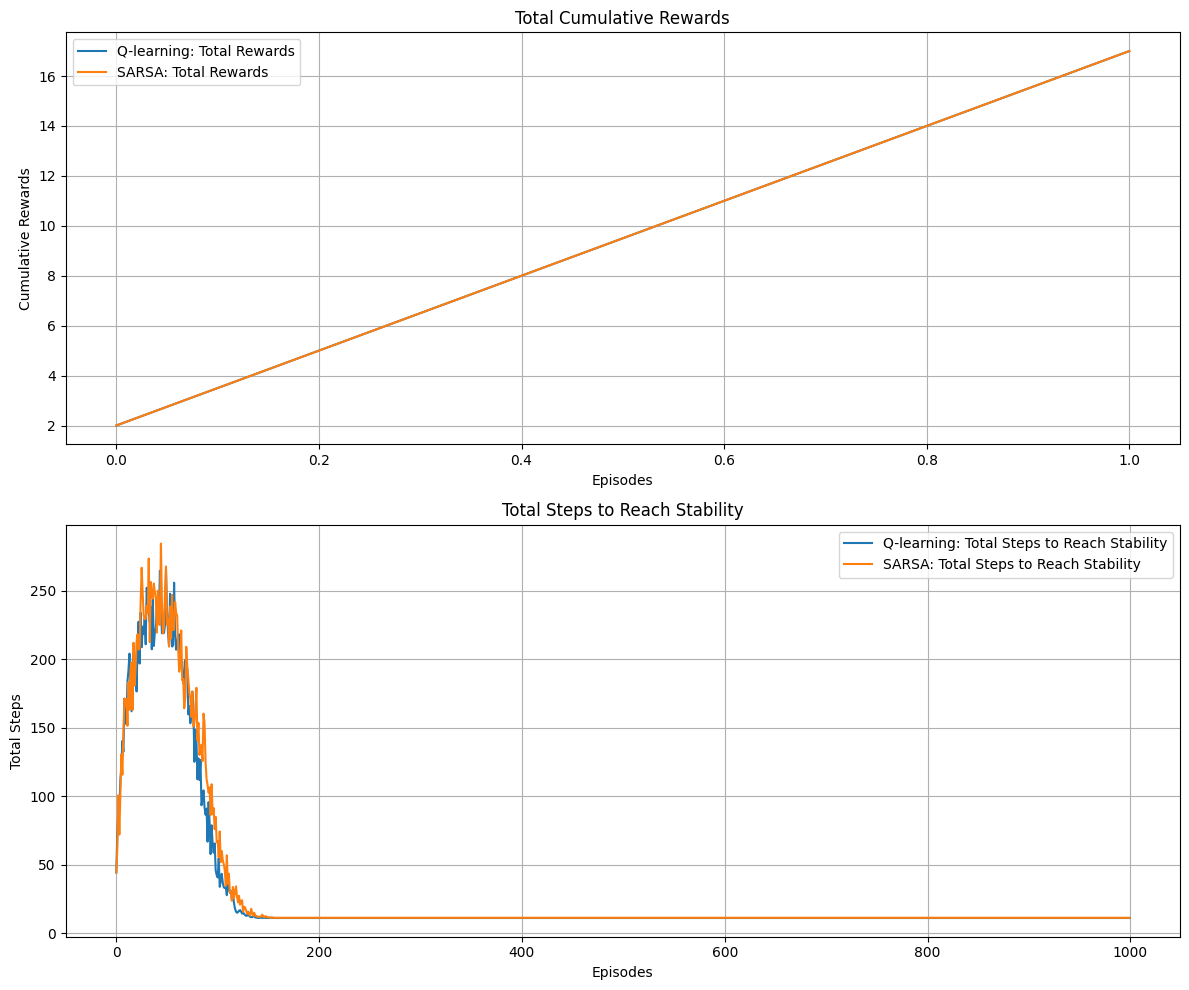

Q-learning Stability Points: [92, 95, 104, 99, 127, 144, 136, 99, 123, 163, 113, 118, 115, 136, 106, 106, 147, 143, 131, 104, 113, 121, 105, 100, 112, 130, 94, 96, 122, 127, 115, 120, 131, 111, 106, 122, 134, 94, 94, 93, 108, 132, 95, 137, 93, 99, 126, 129, 95, 96, 105, 109, 135, 121, 126, 117, 115, 79, 139, 129, 97, 100, 108, 91, 102, 134, 120, 96, 143, 133, 141, 115, 135, 162, 151, 141, 96, 99, 92, 134, 87, 130, 107, 128, 142, 117, 140, 115, 109, 128, 105, 112, 100, 106, 140, 112, 124, 129, 124, 102]
SARSA Stability Points: [114, 99, 117, 101, 126, 96, 158, 119, 117, 104, 109, 119, 121, 113, 127, 128, 116, 140, 106, 132, 129, 144, 88, 114, 122, 107, 129, 96, 87, 112, 100, 145, 137, 146, 117, 112, 126, 88, 81, 88, 132, 148, 104, 153, 101, 161, 80, 106, 109, 98, 89, 134, 137, 130, 120, 148, 117, 165, 107, 131, 122, 126, 153, 141, 113, 139, 134, 137, 126, 87, 115, 127, 139, 127, 123, 148, 99, 148, 101, 112, 138, 139, 121, 143, 148, 131, 141, 114, 141, 111, 144, 131, 112, 100, 124, 158, 

In [11]:
# Not implemented correctly
# Function to aggregate rewards from all goals
# def aggregate_rewards(total_rewards):
#     aggregated_rewards = []
#     for episode_rewards in total_rewards:
#         if isinstance(episode_rewards, dict):
#             aggregated_rewards.append(sum(episode_rewards.values()))
#         elif isinstance(episode_rewards, tuple):
#             aggregated_rewards.append(sum(episode_rewards))
#         else:
#             raise TypeError("Unexpected data type in total_rewards")
#     return aggregated_rewards

# # Aggregate total rewards for Q-learning and SARSA
# aggregated_total_rewards_qlearning = [aggregate_rewards(episode) for episode in learning_curves_qlearning['total_rewards']]
# aggregated_total_rewards_sarsa = [aggregate_rewards(episode) for episode in learning_curves_sarsa['total_rewards']]

# # Sum the rewards for each episode to get cumulative rewards
# cumulative_rewards_qlearning = np.cumsum(aggregated_total_rewards_qlearning, axis=1)
# cumulative_rewards_sarsa = np.cumsum(aggregated_total_rewards_sarsa, axis=1)

# # Calculate average total rewards and steps across seeds
# avg_cumulative_rewards_qlearning = np.mean(cumulative_rewards_qlearning, axis=0)
# avg_cumulative_rewards_sarsa = np.mean(cumulative_rewards_sarsa, axis=0)
# avg_total_steps_qlearning = np.mean(learning_curves_qlearning['total_steps'], axis=0)
# avg_total_steps_sarsa = np.mean(learning_curves_sarsa['total_steps'], axis=0)

# # Plot the learning curves
# plt.figure(figsize=(12, 10))

# plt.subplot(2, 1, 1)
# plt.plot(avg_cumulative_rewards_qlearning, label="Q-learning: Total Rewards")
# plt.plot(avg_cumulative_rewards_sarsa, label="SARSA: Total Rewards")
# plt.xlabel("Episodes")
# plt.ylabel("Cumulative Rewards")
# plt.title("Total Cumulative Rewards")
# plt.legend()
# plt.grid()

# plt.subplot(2, 1, 2)
# plt.plot(avg_total_steps_qlearning, label="Q-learning: Total Steps to Reach Stability")
# plt.plot(avg_total_steps_sarsa, label="SARSA: Total Steps to Reach Stability")
# plt.xlabel("Episodes")
# plt.ylabel("Total Steps")
# plt.title("Total Steps to Reach Stability")
# plt.legend()
# plt.grid()

# plt.tight_layout()
# plt.show()

# # Print stability points
# print(f"Q-learning Stability Points: {stability_points_qlearning}")
# print(f"SARSA Stability Points: {stability_points_sarsa}")

# avg_stability_point_qlearning = np.mean(stability_points_qlearning)
# avg_stability_point_sarsa = np.mean(stability_points_sarsa)

# print(f"Average Q-learning Stability Point: {avg_stability_point_qlearning}")
# print(f"Average SARSA Stability Point: {avg_stability_point_sarsa}")

In [2]:

import numpy as np
import matplotlib.pyplot as plt
from gridworld_env import get_task2_gridworld
from RLagent import QLearningSoftmaxDecayingTauTraces, SARSASoftmaxDecayingTauTraces

gridworld = get_task2_gridworld()

seeds = np.load('seeds.npy')

lambda_values = [0.0, 0.3, 0.5, 0.7, 0.9, 1.0]  # Example lambda values to test

# Initialize dictionaries to store learning curves for each lambda value
results_sarsa = {lambda_trace: {'goal_1_visits': [], 'goal_2_visits': [], 'goal_1_rewards': [], 'goal_2_rewards': []} for lambda_trace in lambda_values}
results_qlearning = {lambda_trace: {'goal_1_visits': [], 'goal_2_visits': [], 'goal_1_rewards': [], 'goal_2_rewards': []} for lambda_trace in lambda_values}

for lambda_trace in lambda_values:
    for seed in seeds:
        # Q-learning
        ql = QLearningSoftmaxDecayingTauTraces(gridworld, tau_initial=1.0, tau_min=0.1, decay_rate=0.99, alpha=0.3, gamma=0.8, lambda_trace=lambda_trace, episodes=1000)
        Q_ql, _, _, _ = ql.solve(seed=seed)
        results_qlearning[lambda_trace]['goal_1_visits'].append(ql.goal_1_visits)
        results_qlearning[lambda_trace]['goal_2_visits'].append(ql.goal_2_visits)
        results_qlearning[lambda_trace]['goal_1_rewards'].append(ql.goal_1_rewards)
        results_qlearning[lambda_trace]['goal_2_rewards'].append(ql.goal_2_rewards)

        # SARSA
        sarsa = SARSASoftmaxDecayingTauTraces(gridworld, tau_initial=1.0, tau_min=0.1, decay_rate=0.99, alpha=0.3, gamma=0.8, lambda_trace=lambda_trace, episodes=1000)
        Q_sarsa, _, _, _ = sarsa.solve(seed=seed)
        results_sarsa[lambda_trace]['goal_1_visits'].append(sarsa.goal_1_visits)
        results_sarsa[lambda_trace]['goal_2_visits'].append(sarsa.goal_2_visits)
        results_sarsa[lambda_trace]['goal_1_rewards'].append(sarsa.goal_1_rewards)
        results_sarsa[lambda_trace]['goal_2_rewards'].append(sarsa.goal_2_rewards)

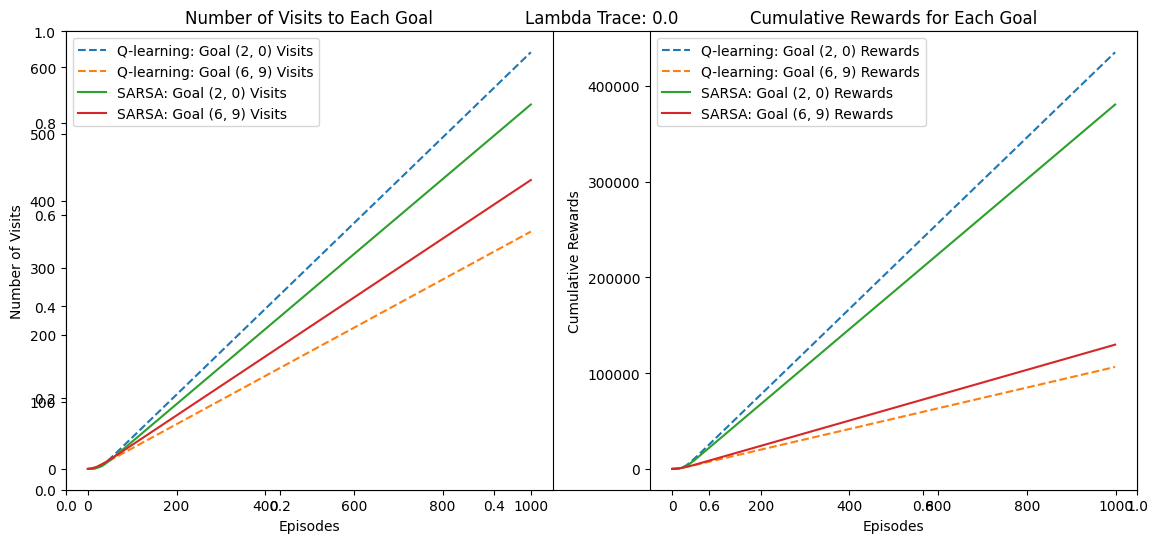

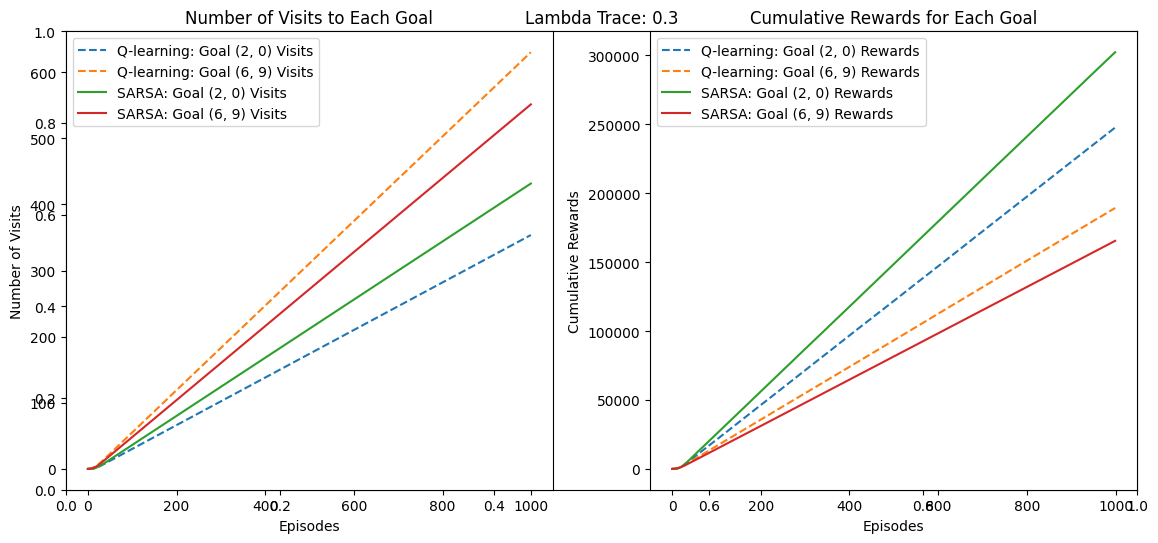

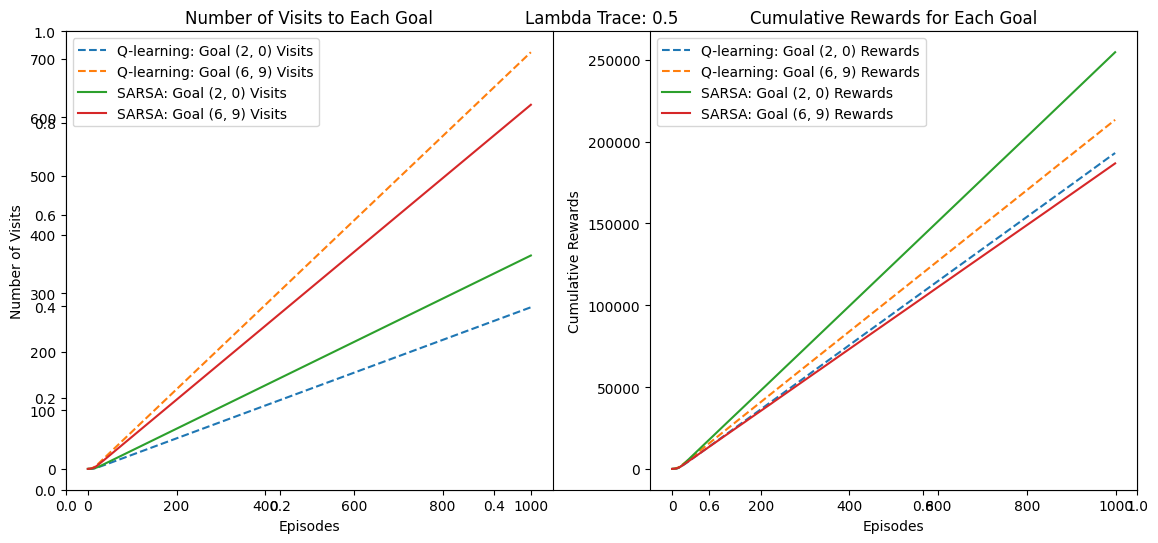

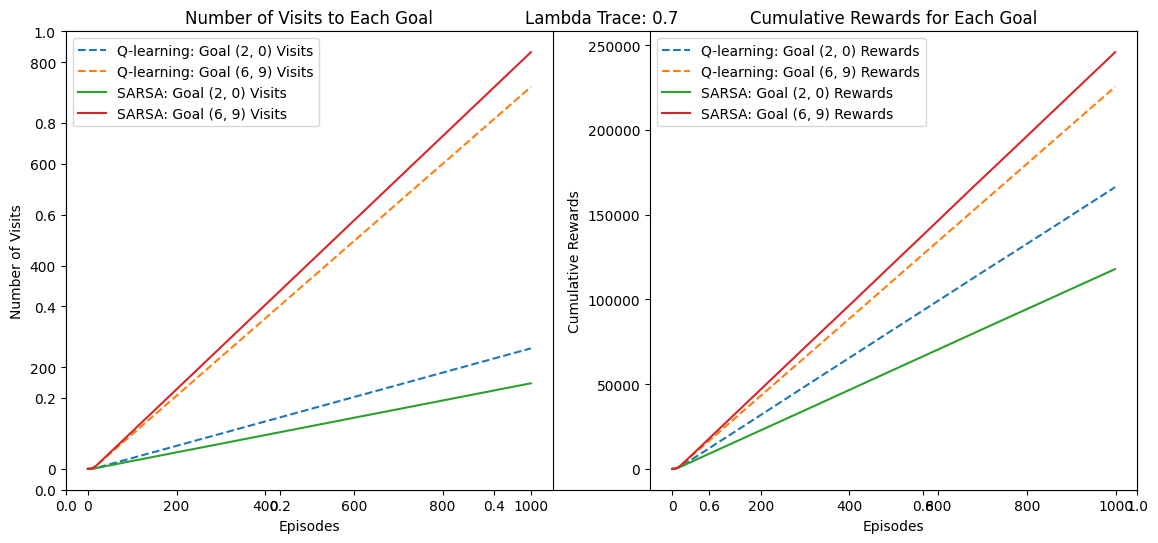

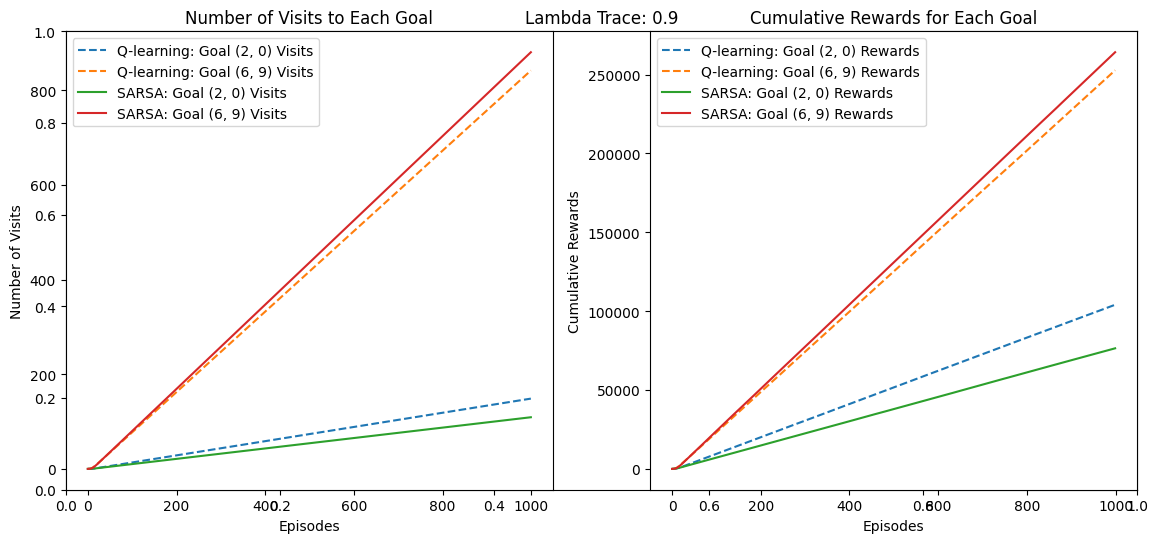

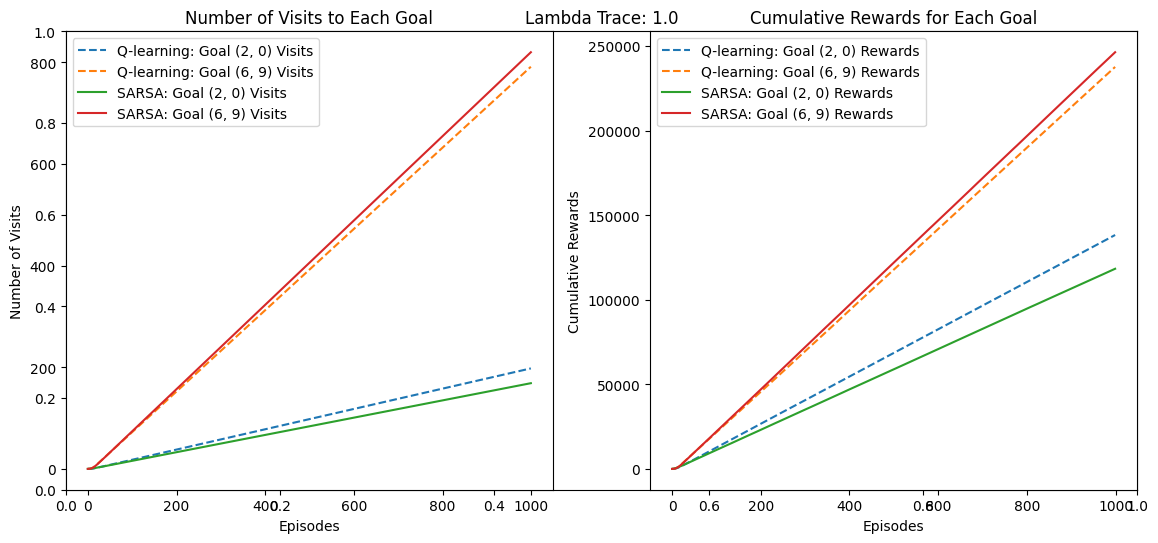

In [ ]:

for lambda_trace in lambda_values:
    
    ql_goal_1_visits = np.mean(results_qlearning[lambda_trace]['goal_1_visits'], axis=0)
    ql_goal_2_visits = np.mean(results_qlearning[lambda_trace]['goal_2_visits'], axis=0)
    ql_goal_1_rewards = np.mean(results_qlearning[lambda_trace]['goal_1_rewards'], axis=0)
    ql_goal_2_rewards = np.mean(results_qlearning[lambda_trace]['goal_2_rewards'], axis=0)
    
    sarsa_goal_1_visits = np.mean(results_sarsa[lambda_trace]['goal_1_visits'], axis=0)
    sarsa_goal_2_visits = np.mean(results_sarsa[lambda_trace]['goal_2_visits'], axis=0)
    sarsa_goal_1_rewards = np.mean(results_sarsa[lambda_trace]['goal_1_rewards'], axis=0)
    sarsa_goal_2_rewards = np.mean(results_sarsa[lambda_trace]['goal_2_rewards'], axis=0)
    
    # Plot combined learning curves for visits and rewards
    plt.figure(figsize=(12, 6))
    plt.title(f"Lambda Trace: {lambda_trace}")

    # Plot for visits to each goal
    plt.subplot(1, 2, 1)
    plt.plot(ql_goal_1_visits, label="Q-learning: Goal (2, 0) Visits", linestyle='--')
    plt.plot(ql_goal_2_visits, label="Q-learning: Goal (6, 9) Visits", linestyle='--')
    plt.plot(sarsa_goal_1_visits, label="SARSA: Goal (2, 0) Visits", linestyle='-')
    plt.plot(sarsa_goal_2_visits, label="SARSA: Goal (6, 9) Visits", linestyle='-')
    plt.xlabel("Episodes")
    plt.ylabel("Number of Visits")
    plt.title("Number of Visits to Each Goal")
    plt.legend()

    # Plot for cumulative rewards for each goal
    plt.subplot(1, 2, 2)
    plt.plot(ql_goal_1_rewards, label="Q-learning: Goal (2, 0) Rewards", linestyle='--')
    plt.plot(ql_goal_2_rewards, label="Q-learning: Goal (6, 9) Rewards", linestyle='--')
    plt.plot(sarsa_goal_1_rewards, label="SARSA: Goal (2, 0) Rewards", linestyle='-')
    plt.plot(sarsa_goal_2_rewards, label="SARSA: Goal (6, 9) Rewards", linestyle='-')
    plt.xlabel("Episodes")
    plt.ylabel("Cumulative Rewards")
    plt.title("Cumulative Rewards for Each Goal")
    plt.legend()

    plt.tight_layout()
    plt.show()



# Task 3 - Stochastic Transitions and Rewards

In [ ]:
# This should be the definition of the gridworld for task 1. DO NOT CHANGE THIS
env3 = get_task3_gridworld()

In [ ]:
# Example of running SARSA
agent = SARSA_agent()
policy, total_rewards, total_steps = agent.solve(env3)

In [ ]:
# Example of running Q-Learning
agent = Q_agent()
policy, total_rewards, total_steps = agent.solve(env3)

In [ ]:
# Do your plots below! Include any new function definitions in this jupyter notebook!

Running Task 2 final algorithm on task 3


In [23]:
env3 = get_task3_gridworld()

seeds = np.load('seeds.npy')
learning_curves_sarsa = {'goal_1_visits': [], 'goal_2_visits': [], 'goal_1_rewards': [], 'goal_2_rewards': []}
learning_curves_qlearning = {'goal_1_visits': [], 'goal_2_visits': [], 'goal_1_rewards': [], 'goal_2_rewards': []}

for seed in seeds:
    # Q-learning
    ql = QLearningSoftmaxDecayingTauTraces(env3, tau_initial=1.0, tau_min=0.1, decay_rate=0.99, alpha=0.01, gamma=0.9, lambda_trace=0.01, episodes=1000)
    Q_ql, _, _, _ = ql.solve(seed=seed)
    learning_curves_qlearning['goal_1_visits'].append(ql.goal_1_visits)
    learning_curves_qlearning['goal_2_visits'].append(ql.goal_2_visits)
    learning_curves_qlearning['goal_1_rewards'].append(ql.goal_1_rewards)
    learning_curves_qlearning['goal_2_rewards'].append(ql.goal_2_rewards)

    # SARSA
    sarsa = SARSASoftmaxDecayingTauTraces(env3, tau_initial=1.0, tau_min=0.1, decay_rate=0.99, alpha=0.01, gamma=0.9, lambda_trace=0.01, episodes=1000)
    Q_sarsa, _, _, _ = sarsa.solve(seed=seed)
    learning_curves_sarsa['goal_1_visits'].append(sarsa.goal_1_visits)
    learning_curves_sarsa['goal_2_visits'].append(sarsa.goal_2_visits)
    learning_curves_sarsa['goal_1_rewards'].append(sarsa.goal_1_rewards)
    learning_curves_sarsa['goal_2_rewards'].append(sarsa.goal_2_rewards)


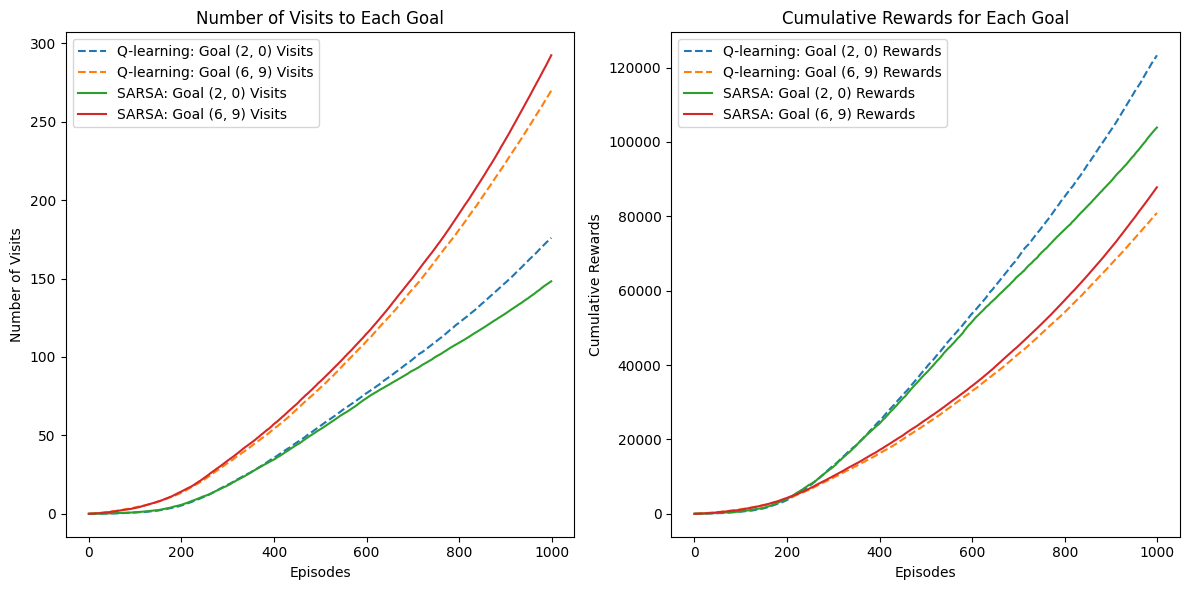

In [28]:
# Average learning curve data across seeds
avg_goal_1_visits_qlearning = np.mean(learning_curves_qlearning['goal_1_visits'], axis=0)
avg_goal_2_visits_qlearning = np.mean(learning_curves_qlearning['goal_2_visits'], axis=0)
avg_goal_1_rewards_qlearning = np.mean(learning_curves_qlearning['goal_1_rewards'], axis=0)
avg_goal_2_rewards_qlearning = np.mean(learning_curves_qlearning['goal_2_rewards'], axis=0)

avg_goal_1_visits_sarsa = np.mean(learning_curves_sarsa['goal_1_visits'], axis=0)
avg_goal_2_visits_sarsa = np.mean(learning_curves_sarsa['goal_2_visits'], axis=0)
avg_goal_1_rewards_sarsa = np.mean(learning_curves_sarsa['goal_1_rewards'], axis=0)
avg_goal_2_rewards_sarsa = np.mean(learning_curves_sarsa['goal_2_rewards'], axis=0)

# Plot combined learning curves for visits and rewards
plt.figure(figsize=(12, 6))

# Plot for visits to each goal
plt.subplot(1, 2, 1)
plt.plot(avg_goal_1_visits_qlearning, label="Q-learning: Goal (2, 0) Visits", linestyle='--')
plt.plot(avg_goal_2_visits_qlearning, label="Q-learning: Goal (6, 9) Visits", linestyle='--')
plt.plot(avg_goal_1_visits_sarsa, label="SARSA: Goal (2, 0) Visits", linestyle='-')
plt.plot(avg_goal_2_visits_sarsa, label="SARSA: Goal (6, 9) Visits", linestyle='-')
plt.xlabel("Episodes")
plt.ylabel("Number of Visits")
plt.title("Number of Visits to Each Goal")
plt.legend()

# Plot for cumulative rewards for each goal
plt.subplot(1, 2, 2)
plt.plot(avg_goal_1_rewards_qlearning, label="Q-learning: Goal (2, 0) Rewards", linestyle='--')
plt.plot(avg_goal_2_rewards_qlearning, label="Q-learning: Goal (6, 9) Rewards", linestyle='--')
plt.plot(avg_goal_1_rewards_sarsa, label="SARSA: Goal (2, 0) Rewards", linestyle='-')
plt.plot(avg_goal_2_rewards_sarsa, label="SARSA: Goal (6, 9) Rewards", linestyle='-')
plt.xlabel("Episodes")
plt.ylabel("Cumulative Rewards")
plt.title("Cumulative Rewards for Each Goal")
plt.legend()

plt.tight_layout()
plt.show()

NOW, instead of traces, doing with ANN

ANN without Backpropogation and Gradient Descent

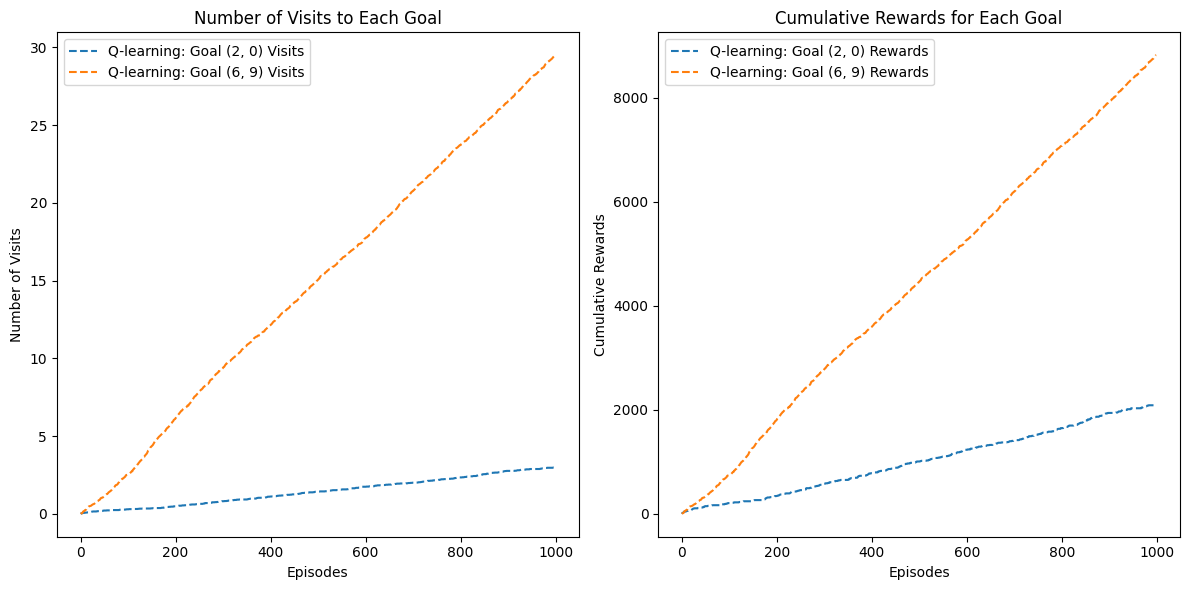

In [8]:
import numpy as np
from gridworld_env import GridWorld, get_task3_gridworld
import matplotlib.pyplot as plt

class SimpleNeuralNetworkReLU:
    def __init__(self, input_size, output_size, learning_rate=0.01):
        self.input_size = input_size
        self.output_size = output_size
        self.learning_rate = learning_rate

        # Initialize weights using standard normal distribution
        self.weights = np.random.randn(input_size, output_size) * np.sqrt(2. / input_size)
        self.bias = np.zeros((1, output_size))

    def relu(self, x):
        return np.maximum(0, x)

    def predict(self, state):
        linear_output = np.dot(state, self.weights) + self.bias
        return self.relu(linear_output)

    def update(self, state, target):
        output = self.predict(state)
        error = target - output

        # Directly update weights and biases
        self.weights += self.learning_rate * np.dot(state.T, error) 
        self.bias += self.learning_rate * error

class QLearningANNReLU:
    def __init__(self, env: GridWorld, tau_initial=1.0, tau_min=0.1, decay_rate=0.99, alpha=0.01, gamma=0.9, episodes=1000):
        self.env = env
        self.tau = tau_initial
        self.tau_min = tau_min
        self.decay_rate = decay_rate
        self.alpha = alpha
        self.gamma = gamma
        self.episodes = episodes
        self.state_size = env.get_state_size()
        self.action_size = env.get_action_size()
        self.q_network = SimpleNeuralNetworkReLU(self.state_size, self.action_size, self.alpha)
        self.goal_1_visits = []
        self.goal_2_visits = []
        self.goal_1_rewards = []
        self.goal_2_rewards = []
        self.total_steps = 0 

    def softmax(self, q_values, tau):
        q_adjusted = q_values - np.max(q_values)
        exp_q = np.exp(q_adjusted / tau)
        sum_exp_q = np.sum(exp_q, axis=1, keepdims=True)
        return exp_q / sum_exp_q

    def choose_action(self, state):
        q_values = self.q_network.predict(state)
        action_probs = self.softmax(q_values, self.tau)
        return np.random.choice(self.action_size, p=action_probs[0])

    def solve(self, seed=None):
        np.random.seed(seed)
        goal_visits = {goal: 0 for goal in self.env.get_goal_loc()}
        cumulative_rewards = {goal: 0 for goal in self.env.get_goal_loc()}

        for episode in range(self.episodes):
            t, state, reward, done = self.env.reset()
            one_hot_state = np.eye(self.state_size)[state].reshape(1, -1)

            while not done:
                action = self.choose_action(one_hot_state)
                t, next_state, reward, done = self.env.step(action)
                next_one_hot_state = np.eye(self.state_size)[next_state].reshape(1, -1)

                best_next_action = np.argmax(self.q_network.predict(next_one_hot_state))
                td_target = reward + self.gamma * self.q_network.predict(next_one_hot_state)[0][best_next_action]
                target_f = self.q_network.predict(one_hot_state)[0]
                target_f[action] = td_target
                self.q_network.update(one_hot_state, target_f.reshape(1, -1))

                one_hot_state = next_one_hot_state
                state = next_state

            for goal in self.env.get_goal_loc():
                goal_state = self.env._get_state_from_loc(goal)
                if state == goal_state:
                    goal_visits[goal] += 1
                    cumulative_rewards[goal] += reward

            self.goal_1_visits.append(goal_visits[self.env.get_goal_loc()[0]])
            self.goal_2_visits.append(goal_visits[self.env.get_goal_loc()[1]])
            self.goal_1_rewards.append(cumulative_rewards[self.env.get_goal_loc()[0]])
            self.goal_2_rewards.append(cumulative_rewards[self.env.get_goal_loc()[1]])

            self.tau = max(self.tau_min, self.tau * self.decay_rate)
        
        return self.q_network, goal_visits, cumulative_rewards, self.total_steps

class SARSANNReLU:
    def __init__(self, env: GridWorld, tau_initial=1.0, tau_min=0.1, decay_rate=0.99, alpha=0.01, gamma=0.9, episodes=1000):
        self.env = env
        self.tau = tau_initial
        self.tau_min = tau_min
        self.decay_rate = decay_rate
        self.alpha = alpha
        self.gamma = gamma
        self.episodes = episodes
        self.state_size = env.get_state_size()
        self.action_size = env.get_action_size()
        self.q_network = SimpleNeuralNetworkReLU(self.state_size, self.action_size, self.alpha)
        self.goal_1_visits = []
        self.goal_2_visits = []
        self.goal_1_rewards = []
        self.goal_2_rewards = []
        self.total_steps = 0 

    def softmax(self, q_values, tau):
        q_adjusted = q_values - np.max(q_values)
        exp_q = np.exp(q_adjusted / tau)
        sum_exp_q = np.sum(exp_q, axis=1, keepdims=True)
        return exp_q / sum_exp_q

    def choose_action(self, state):
        q_values = self.q_network.predict(state)
        action_probs = self.softmax(q_values, self.tau)
        return np.random.choice(self.action_size, p=action_probs[0])

    def solve(self, seed=None):
        np.random.seed(seed)
        goal_visits = {goal: 0 for goal in self.env.get_goal_loc()}
        cumulative_rewards = {goal: 0 for goal in self.env.get_goal_loc()}

        for episode in range(self.episodes):
            t, state, reward, done = self.env.reset()
            one_hot_state = np.eye(self.state_size)[state].reshape(1, -1)

            action = self.choose_action(one_hot_state)

            while not done:
                t, next_state, reward, done = self.env.step(action)
                next_one_hot_state = np.eye(self.state_size)[next_state].reshape(1, -1)
                next_action = self.choose_action(next_one_hot_state)

                td_target = reward + self.gamma * self.q_network.predict(next_one_hot_state)[0][next_action]
                target_f = self.q_network.predict(one_hot_state)[0]
                target_f[action] = td_target
                self.q_network.update(one_hot_state, target_f.reshape(1, -1))

                one_hot_state = next_one_hot_state
                action = next_action
                state = next_state

            for goal in self.env.get_goal_loc():
                goal_state = self.env._get_state_from_loc(goal)
                if state == goal_state:
                    goal_visits[goal] += 1
                    cumulative_rewards[goal] += reward

            self.goal_1_visits.append(goal_visits[self.env.get_goal_loc()[0]])
            self.goal_2_visits.append(goal_visits[self.env.get_goal_loc()[1]])
            self.goal_1_rewards.append(cumulative_rewards[self.env.get_goal_loc()[0]])
            self.goal_2_rewards.append(cumulative_rewards[self.env.get_goal_loc()[1]])

            self.tau = max(self.tau_min, self.tau * self.decay_rate)
        
        return self.q_network, goal_visits, cumulative_rewards, self.total_steps

# Example usage:
env3 = get_task3_gridworld()
seeds = np.load('seeds.npy')

learning_curves_qlearning = {'goal_1_visits': [], 'goal_2_visits': [], 'goal_1_rewards': [], 'goal_2_rewards': []}
learning_curves_sarsa = {'goal_1_visits': [], 'goal_2_visits': [], 'goal_1_rewards': [], 'goal_2_rewards': []}


for seed in seeds:
    ql = QLearningANNReLU(env3, tau_initial=1.0, tau_min=0.1, decay_rate=0.99, alpha=0.001, gamma=0.9, episodes=1000)
    Q_ql, goal_visits, cumulative_rewards, total_steps = ql.solve(seed=seed)
    learning_curves_qlearning['goal_1_visits'].append(ql.goal_1_visits)
    learning_curves_qlearning['goal_2_visits'].append(ql.goal_2_visits)
    learning_curves_qlearning['goal_1_rewards'].append(ql.goal_1_rewards)
    learning_curves_qlearning['goal_2_rewards'].append(ql.goal_2_rewards)

    sarsa = SARSANNReLU(env3, tau_initial=1.0, tau_min=0.1, decay_rate=0.99, alpha=0.001, gamma=0.9, episodes=1000)
    Q_sarsa, goal_visits, cumulative_rewards, total_steps = sarsa.solve(seed=seed)
    learning_curves_sarsa['goal_1_visits'].append(sarsa.goal_1_visits)
    learning_curves_sarsa['goal_2_visits'].append(sarsa.goal_2_visits)
    learning_curves_sarsa['goal_1_rewards'].append(sarsa.goal_1_rewards)
    learning_curves_sarsa['goal_2_rewards'].append(sarsa.goal_2_rewards)


avg_goal_1_visits_qlearning = np.mean(learning_curves_qlearning['goal_1_visits'], axis=0)
avg_goal_2_visits_qlearning = np.mean(learning_curves_qlearning['goal_2_visits'], axis=0)
avg_goal_1_rewards_qlearning = np.mean(learning_curves_qlearning['goal_1_rewards'], axis=0)
avg_goal_2_rewards_qlearning = np.mean(learning_curves_qlearning['goal_2_rewards'], axis=0)


plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(avg_goal_1_visits_qlearning, label="Q-learning: Goal (2, 0) Visits", linestyle='--')
plt.plot(avg_goal_2_visits_qlearning, label="Q-learning: Goal (6, 9) Visits", linestyle='--')
plt.xlabel("Episodes")
plt.ylabel("Number of Visits")
plt.title("Number of Visits to Each Goal")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(avg_goal_1_rewards_qlearning, label="Q-learning: Goal (2, 0) Rewards", linestyle='--')
plt.plot(avg_goal_2_rewards_qlearning, label="Q-learning: Goal (6, 9) Rewards", linestyle='--')
plt.xlabel("Episodes")
plt.ylabel("Cumulative Rewards")
plt.title("Cumulative Rewards for Each Goal")
plt.legend()

plt.tight_layout()
plt.show()


ANN with Backpropogation and Gradient Descent

In [5]:
env3 = get_task3_gridworld()

seeds = np.load('seeds.npy')
learning_curves_sarsa = {'goal_1_visits': [], 'goal_2_visits': [], 'goal_1_rewards': [], 'goal_2_rewards': []}
learning_curves_qlearning = {'goal_1_visits': [], 'goal_2_visits': [], 'goal_1_rewards': [], 'goal_2_rewards': []}


for seed in seeds:
    # Q-learning
    ql = QLearningANN(env3, tau_initial=1.0, tau_min=0.1, decay_rate=0.99, alpha=0.001, gamma=0.9, episodes=1000)
    Q_ql, _, _, _ = ql.solve(seed=seed)
    learning_curves_qlearning['goal_1_visits'].append(ql.goal_1_visits)
    learning_curves_qlearning['goal_2_visits'].append(ql.goal_2_visits)
    learning_curves_qlearning['goal_1_rewards'].append(ql.goal_1_rewards)
    learning_curves_qlearning['goal_2_rewards'].append(ql.goal_2_rewards)

    # SARSA
    sarsa = SARSAANN(env3, tau_initial=1.0, tau_min=0.1, decay_rate=0.99, alpha=0.001, gamma=0.9, episodes=1000)
    Q_sarsa, _, _, _ = sarsa.solve(seed=seed)
    learning_curves_sarsa['goal_1_visits'].append(sarsa.goal_1_visits)
    learning_curves_sarsa['goal_2_visits'].append(sarsa.goal_2_visits)
    learning_curves_sarsa['goal_1_rewards'].append(sarsa.goal_1_rewards)
    learning_curves_sarsa['goal_2_rewards'].append(sarsa.goal_2_rewards)


KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt

avg_goal_1_visits_qlearning = np.mean(learning_curves_qlearning['goal_1_visits'], axis=0)
avg_goal_2_visits_qlearning = np.mean(learning_curves_qlearning['goal_2_visits'], axis=0)
avg_goal_1_rewards_qlearning = np.mean(learning_curves_qlearning['goal_1_rewards'], axis=0)
avg_goal_2_rewards_qlearning = np.mean(learning_curves_qlearning['goal_2_rewards'], axis=0)

avg_goal_1_visits_sarsa = np.mean(learning_curves_sarsa['goal_1_visits'], axis=0)
avg_goal_2_visits_sarsa = np.mean(learning_curves_sarsa['goal_2_visits'], axis=0)
avg_goal_1_rewards_sarsa = np.mean(learning_curves_sarsa['goal_1_rewards'], axis=0)
avg_goal_2_rewards_sarsa = np.mean(learning_curves_sarsa['goal_2_rewards'], axis=0)


plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(avg_goal_1_visits_qlearning, label="Q-learning: Goal (2, 0) Visits", linestyle='--')
plt.plot(avg_goal_2_visits_qlearning, label="Q-learning: Goal (6, 9) Visits", linestyle='--')
plt.plot(avg_goal_1_visits_sarsa, label="SARSA: Goal (2, 0) Visits", linestyle='-')
plt.plot(avg_goal_2_visits_sarsa, label="SARSA: Goal (6, 9) Visits", linestyle='-')
plt.xlabel("Episodes")
plt.ylabel("Number of Visits")
plt.title("Number of Visits to Each Goal")
plt.legend()

# Plot for cumulative rewards for each goal
plt.subplot(1, 2, 2)
plt.plot(avg_goal_1_rewards_qlearning, label="Q-learning: Goal (2, 0) Rewards", linestyle='--')
plt.plot(avg_goal_2_rewards_qlearning, label="Q-learning: Goal (6, 9) Rewards", linestyle='--')
plt.plot(avg_goal_1_rewards_sarsa, label="SARSA: Goal (2, 0) Rewards", linestyle='-')
plt.plot(avg_goal_2_rewards_sarsa, label="SARSA: Goal (6, 9) Rewards", linestyle='-')
plt.xlabel("Episodes")
plt.ylabel("Cumulative Rewards")
plt.title("Cumulative Rewards for Each Goal")
plt.legend()

plt.tight_layout()
plt.show()